<a href="https://colab.research.google.com/github/NBELab/Cogsci2026/blob/main/Notebooks/CogSci_2026_EMD_sparate_rebound_LIF_and_non_separte_LIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nengo


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.3/542.3 kB 10.3 MB/s eta 0:00:00


In [2]:
%matplotlib inline
import nengo
from nengo.synapses import Synapse
import matplotlib.pyplot as plt
import numpy as np
from nengo.params import NumberParam
from nengo.utils.filter_design import tf2ss
from nengo.synapses import LinearFilter
from nengo.dists import Choice, Uniform
from nengo.processes import Piecewise
from collections import deque




In [7]:
#non separate EMD (coupled)
def build__non_separate_model(deltaT_ms = 10,left_stim=5,right_stim=-5):

  present_time = 0.01

  num_neurons_ens = 2


  synapse = 0.001



  delay_time = 0.01+present_time # Delay in seconds
  dt = 0.001  # Simulation time step
  buffer_length = int(delay_time / dt)  # Buffer size based on delay time

  hp_tau = 0.01 #delay_time/2
  lp_tau = 0.005 #delay_time/2
  tau_high = 0
  tau_low = 2

  dt = 0.001
  class Delay:
      def __init__(self, dimensions, timesteps=50):
          self.history = np.zeros((timesteps, dimensions))

      def step(self, t, x):
          self.history = np.roll(self.history, -1,axis=0)
          self.history[-1,:] = x
          return self.history[0,:]

  dt = 0.001


  trans = 1/3



  trans = 1/3
  neuron_type = nengo.RectifiedLinear()

  with nengo.Network(seed=0) as model:

    input_func1 = Piecewise({0: 0, 0.2: left_stim, 0.2+present_time: 0})
    input_func2 = Piecewise({0: 0, 0.2+deltaT_ms/1000+present_time: right_stim, 0.2+deltaT_ms/1000+2*present_time: 0})
    input_n_left = nengo.Node(input_func1, size_out=1)
    input_n_right = nengo.Node(input_func2, size_out=1)








    layer_left_on =  nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )
    layer_right_on = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )

    layer_left_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )
    layer_right_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )

    nengo.Connection(input_n_left,layer_left_on,transform=1.0)
    nengo.Connection(input_n_left,layer_left_off,transform=1.0)
    nengo.Connection(input_n_right,layer_right_on,transform=1.0)
    nengo.Connection(input_n_right,layer_right_off,transform=1.0)



    encoders_on = np.array([
        [ 1,  0],  # Neuron 1: Prefers positive direction in 1st dim
        [ 0,  1],  # Neuron 2: Prefers negative direction in 2st dim

    ])

    encoders_off = np.array([
        [ -1, 0],  # Neuron 1: Prefers positive direction in 1st dim
        [ 0, -1],  # Neuron 2: Prefers negative direction in 2st dim

    ])



    product_output_left = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )
    product_output_right = nengo.Ensemble(
        1, 1,
        intercepts=Uniform(0.0, 0.0),
        max_rates=Uniform(150, 150),
        seed=1,
        neuron_type=neuron_type,
        encoders=[[1]]
    )

    product_output_left_on_pos = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_left_off_pos = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_right_on_pos = nengo.Ensemble(
        1, 1,
        intercepts=Uniform(0.0, 0.0),
        max_rates=Uniform(150, 150),
        seed=1,
        neuron_type=neuron_type,
        encoders=[[1]]
    )
    product_output_right_off_pos = nengo.Ensemble(
        1, 1,
        intercepts=Uniform(0.0, 0.0),
        max_rates=Uniform(150, 150),
        seed=1,
        neuron_type=neuron_type,
        encoders=[[1]]
    )


    product_output_left_on_neg = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_left_off_neg = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_right_on_neg = nengo.Ensemble(
        1, 1,
        intercepts=Uniform(0.0, 0.0),
        max_rates=Uniform(150, 150),
        seed=1,
        neuron_type=neuron_type,
        encoders=[[1]]
    )
    product_output_right_off_neg = nengo.Ensemble(
        1, 1,
        intercepts=Uniform(0.0, 0.0),
        max_rates=Uniform(150, 150),
        seed=1,
        neuron_type=neuron_type,
        encoders=[[1]]
    )

    delay_ens_l_on = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )

    delay_ens_r_on = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )

    delay_ens_l_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )

    delay_ens_r_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )




    tau_low = 0.2
    tau_high = 0
    db_delay = 0.01

    delay_transform = 1

    nengo.Connection(layer_left_on,delay_ens_l_on,synapse=0.2,transform=delay_transform)
    nengo.Connection(layer_right_on,delay_ens_r_on,synapse=0.2,transform=delay_transform)
    nengo.Connection(layer_left_off,delay_ens_l_off,synapse=0.2,transform=delay_transform)
    nengo.Connection(layer_right_off,delay_ens_r_off,synapse=0.2,transform=delay_transform)

    b=0.5
    bias_on = nengo.Node(output=-1)
    bias_off = nengo.Node(output=-1)
    transform = 1



    nengo.Connection(delay_ens_l_on,product_output_right_on_pos)
    nengo.Connection(layer_right_on,product_output_right_on_pos)

    nengo.Connection(delay_ens_l_off,product_output_right_off_pos,transform=-1)
    nengo.Connection(layer_right_off,product_output_right_off_pos,transform=-1)

    nengo.Connection(delay_ens_l_on,product_output_right_on_neg)
    nengo.Connection(layer_right_off,product_output_right_on_neg,transform=-1)

    nengo.Connection(delay_ens_l_off,product_output_right_off_neg,transform=-1)
    nengo.Connection(layer_right_on,product_output_right_off_neg)


    nengo.Connection(bias_on, product_output_right_on_pos)
    nengo.Connection(bias_on, product_output_right_off_pos)
    nengo.Connection(bias_off, product_output_right_on_neg)
    nengo.Connection(bias_off, product_output_right_off_neg)




    sum = nengo.Ensemble(2,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1],[-1]] )

    nengo.Connection(product_output_right_on_pos,sum,transform=10)

    nengo.Connection(product_output_right_off_pos,sum,transform=10)


    nengo.Connection(product_output_right_on_neg,sum,transform=-10)

    nengo.Connection(product_output_right_off_neg,sum,transform=-10)



    left_on = nengo.Probe(layer_left_on)
    left_off = nengo.Probe(layer_left_off)
    rigth_on = nengo.Probe(layer_right_on)
    rigth_off = nengo.Probe(layer_right_off)
    input_left = nengo.Probe(input_n_left)
    input_right = nengo.Probe(input_n_right)


    product_output_right_on_pos_p = nengo.Probe(product_output_right_on_pos)
    product_output_right_off_pos_p = nengo.Probe(product_output_right_off_pos)
    product_output_right_on_neg_p = nengo.Probe(product_output_right_on_neg)
    product_output_right_off_neg_p = nengo.Probe(product_output_right_off_neg)

    delay_ens_l_off_p = nengo.Probe(delay_ens_l_off)
    delay_ens_r_off_p = nengo.Probe(delay_ens_r_off)
    delay_ens_l_on_p = nengo.Probe(delay_ens_l_on)
    delay_ens_r_on_p = nengo.Probe(delay_ens_r_on)


    sum_p = nengo.Probe(sum)

    return model,sum_p

In [8]:
#phi
import numpy as np
import nengo

Delta_Ts = [0,10, 20,30,40, 50, 60, 70, 80, 90,100]
max_respons = np.zeros(len(Delta_Ts))
t_at_max = np.zeros(len(Delta_Ts))

for i, DT in enumerate(Delta_Ts):

    model, sum_p = build__non_separate_model(DT,left_stim=-5,right_stim=-5)

    runtime = 0.7
    with nengo.Simulator(model,progress_bar=False) as sim:
        sim.run(runtime)


    Y = sim.data[sum_p]     # shape: (T, D)
    t = sim.trange()        # shape: (T,)


    if Y.ndim == 1 or Y.shape[1] == 1:
        y = Y.ravel()
        idx = np.argmax(np.abs(y))
        val = y[idx]
        t_max = t[idx]
    else:

        idx2d = np.unravel_index(np.abs(Y).argmax(), Y.shape)
        val = Y[idx2d]
        t_max = t[idx2d[0]]

    max_respons[i] = val
    t_at_max[i] = t_max

print("max_respons:", max_respons)
print("t_at_max:", t_at_max)

max_respons: [1.65710207 1.69713177 1.63891983 1.56342254 1.48792382 1.41547879
 1.34646432 1.28079946 1.21833459 1.15891578 1.1023948 ]
t_at_max: [0.234 0.244 0.254 0.264 0.274 0.284 0.294 0.304 0.314 0.324 0.334]


In [9]:
#reverse phi
import numpy as np
import nengo

Delta_Ts = [0,10, 20,30,40, 50, 60, 70, 80, 90,100]
max_respons = np.zeros(len(Delta_Ts))
t_at_max = np.zeros(len(Delta_Ts))

for i, DT in enumerate(Delta_Ts):

    model, sum_p = build__non_separate_model(DT,left_stim=-5,right_stim=5)

    runtime = 0.7
    with nengo.Simulator(model,progress_bar=False) as sim:
        sim.run(runtime)


    Y = sim.data[sum_p]     # shape: (T, D)
    t = sim.trange()        # shape: (T,)


    if Y.ndim == 1 or Y.shape[1] == 1:
        y = Y.ravel()
        idx = np.argmax(np.abs(y))
        val = y[idx]
        t_max = t[idx]
    else:

        idx2d = np.unravel_index(np.abs(Y).argmax(), Y.shape)
        val = Y[idx2d]
        t_max = t[idx2d[0]]

    max_respons[i] = val
    t_at_max[i] = t_max

print("max_respons:", max_respons)
print("t_at_max:", t_at_max)

max_respons: [-1.65750939 -1.69754892 -1.63932268 -1.56380683 -1.48828955 -1.41582672
 -1.34679529 -1.28111428 -1.21863405 -1.15920064 -1.10266577]
t_at_max: [0.234 0.244 0.254 0.264 0.274 0.284 0.294 0.304 0.314 0.324 0.334]


In [10]:
# rebound mechanism
import nengo
import numpy as np


def add_presynaptic_rebound_to_single_neuron_ensemble(
    model,
    ensemble,
    drive,
    polarity=+1.0,
    tau_inhib=0.012,
    tau_delay=0.017,
    tau_rebound=0.010,
    k_inhib=12.0,
    k_rebound=6.0,
    clip_release=True,
):
    """
    Add a presynaptic rebound mechanism to a single-neuron Ensemble.

    This helper is a single-ensemble version of the EA-based function.
    It assumes:
        - `ensemble` is a nengo.Ensemble with exactly one neuron.
        - `drive` is a scalar signal (Node, Ensemble, etc. with size_out == 1)
          that represents the input driving the ensemble.
        - You create your own nengo.Connection(drive, ensemble, ...) separately.
          This function does NOT create that main connection; it only adds
          presynaptic modulation via ensemble.neurons.

    The circuit:
        1. Take `drive` (optionally flip sign with `polarity`) → s_eff.
        2. Split into positive (exc) and negative (inhib) half-wave rectified parts.
        3. Filter `inhib` with two lowpass filters (tau_inhib, tau_delay).
        4. Compute release_raw = delay_lp - inhib_lp.
        5. Optionally ReLU-clip the release signal (clip_release).
        6. Lowpass filter the release to get a rebound term (tau_rebound, k_rebound).
        7. Compute an inhibitory penalty proportional to the negative input
           (-k_inhib * inhib).
        8. Sum exc + rebound + inhib_penalty at a neuron-level input node,
           which feeds into ensemble.neurons.

    Parameters
    ----------
    model : nengo.Network
        The network in which all components are created.
    ensemble : nengo.Ensemble
        Target ensemble. Must have ensemble.n_neurons == 1.
    drive : nengo.Node or other Nengo object
        Scalar signal (size_out == 1) that drives both the ensemble and the rebound circuit.
    polarity : float, optional
        Sign applied to `drive` before processing (+1 for normal, -1 to invert).
    tau_inhib : float, optional
        Lowpass time constant for the inhibition signal.
    tau_delay : float, optional
        Second lowpass constant to create a delayed inhibition.
    tau_rebound : float, optional
        Lowpass time constant for the rebound term.
    k_inhib : float, optional
        Gain for the inhibitory penalty term.
    k_rebound : float, optional
        Gain for the rebound term.
    clip_release : bool, optional
        If True, apply ReLU to (delay_lp - inhib_lp) before rebound filtering.

    Returns
    -------
    dict
        A dictionary with the internal Nodes and the neuron_input:
            {
                "s_eff", "exc", "inhib",
                "inhib_lp", "delay_lp",
                "release", "rebound",
                "inhib_penalty",
                "neuron_input",
            }
    """
    assert ensemble.n_neurons == 1, "This helper assumes a single-neuron Ensemble."
    # We also implicitly assume the driven signal is scalar.
    with model:
        # Effective input from `drive`
        s_eff = nengo.Node(size_in=1, label="s_eff")
        nengo.Connection(
            drive,
            s_eff,
            transform=[[float(np.sign(polarity) or 1.0)]],
            synapse=None,
        )

        # Half-wave rectification
        exc = nengo.Node(
            output=lambda t, x: max(x[0], 0.0),
            size_in=1,
            label="exc",
        )
        inhib = nengo.Node(
            output=lambda t, x: max(-x[0], 0.0),
            size_in=1,
            label="inhib",
        )
        nengo.Connection(s_eff, exc,   synapse=None)
        nengo.Connection(s_eff, inhib, synapse=None)

        # Two lowpass filters on inhibition
        inhib_lp = nengo.Node(size_in=1, label="inhib_lp")
        delay_lp = nengo.Node(size_in=1, label="delay_lp")
        nengo.Connection(inhib,    inhib_lp, synapse=nengo.Lowpass(tau_inhib))
        nengo.Connection(inhib_lp, delay_lp, synapse=nengo.Lowpass(tau_delay))

        # release_raw = delay_lp - inhib_lp
        rel_raw = nengo.Node(
            output=lambda t, x: x[0] - x[1],
            size_in=2,
            size_out=1,
            label="release_raw",
        )
        nengo.Connection(delay_lp, rel_raw[0], synapse=None)
        nengo.Connection(inhib_lp, rel_raw[1], synapse=None)

        # Optional ReLU on release
        if clip_release:
            release = nengo.Node(
                output=lambda t, x: max(x[0], 0.0),
                size_in=1,
                label="release_relu",
            )
            nengo.Connection(rel_raw, release, synapse=None)
        else:
            release = rel_raw

        # Rebound term (lowpass filtered release with gain)
        rebound = nengo.Node(size_in=1, label="rebound")
        nengo.Connection(
            release,
            rebound,
            synapse=nengo.Lowpass(tau_rebound),
            transform=[[k_rebound]],
        )

        # Inhibitory penalty term
        inhib_penalty = nengo.Node(size_in=1, label="inhib_penalty")
        nengo.Connection(
            inhib,
            inhib_penalty,
            synapse=None,
            transform=[[-k_inhib]],
        )

        # Neuron-level input node that feeds into ensemble.neurons
        neuron_input = nengo.Node(
            size_in=ensemble.n_neurons,
            label="rebound_neuron_input",
        )

        # Connect neuron_input to the actual neurons (identity transform)
        nengo.Connection(
            neuron_input,
            ensemble.neurons,
            synapse=None,
        )

        # For a single-neuron ensemble, the transform matrices are 1x1
        ones = np.ones((ensemble.n_neurons, 1))

        nengo.Connection(exc,           neuron_input, transform=ones, synapse=None)
        nengo.Connection(rebound,       neuron_input, transform=ones, synapse=None)
        nengo.Connection(inhib_penalty, neuron_input, transform=ones, synapse=None)

    return {
        "s_eff": s_eff,
        "exc": exc,
        "inhib": inhib,
        "inhib_lp": inhib_lp,
        "delay_lp": delay_lp,
        "release": release,
        "rebound": rebound,
        "inhib_penalty": inhib_penalty,
        "neuron_input": neuron_input,
    }


In [12]:
# separte (uncoupled) channels
def build_model(deltaT_ms = 10,left_stim=5,right_stim=-5):


  present_time = 0.005
  #def run_trial(deltaT_ms, dt=1e-4):
  num_neurons_ens = 2


  synapse = 0.001



  delay_time = 0.01+present_time # Delay in seconds
  dt = 0.001  # Simulation time step
  buffer_length = int(delay_time / dt)  # Buffer size based on delay time

  hp_tau = 0.01
  lp_tau = 0.005
  tau_high = 0
  tau_low = 2

  dt = 0.001



  neuron_type = nengo.LIFRate()

  with nengo.Network(seed=0) as model:

    input_func1 = Piecewise({0: 0, 0.2: left_stim, 0.2+present_time: 0})
    input_func2 = Piecewise({0: 0, 0.2+deltaT_ms/1000+present_time: right_stim, 0.2+deltaT_ms/1000+2*present_time: 0})
    input_n_left = nengo.Node(input_func1, size_out=1)
    input_n_right = nengo.Node(input_func2, size_out=1)








    layer_left_on = nengo.Ensemble(
                                    n_neurons=1, dimensions=1,
                                    neuron_type=nengo.LIFRate(tau_rc=0.02, tau_ref=0.002),
                                    encoders=nengo.dists.Choice([[1.0]]),
                                    intercepts=nengo.dists.Choice([0]),
                                    max_rates=nengo.dists.Choice([150]),
                                          )
    layer_right_on = nengo.Ensemble(
                                    n_neurons=1, dimensions=1,
                                    neuron_type=nengo.LIFRate(tau_rc=0.02, tau_ref=0.002),
                                    encoders=nengo.dists.Choice([[1.0]]),
                                    intercepts=nengo.dists.Choice([0]),
                                    max_rates=nengo.dists.Choice([150]),
                                          )

    layer_left_off = nengo.Ensemble(
                                  n_neurons=1, dimensions=1,
                                  neuron_type=nengo.LIFRate(tau_rc=0.02, tau_ref=0.002),
                                  encoders=nengo.dists.Choice([[-1.0]]),
                                  intercepts=nengo.dists.Choice([0]),
                                  max_rates=nengo.dists.Choice([150]),
                                          )
    layer_right_off = nengo.Ensemble(
                                  n_neurons=1, dimensions=1,
                                  neuron_type=nengo.LIFRate(tau_rc=0.02, tau_ref=0.002),
                                  encoders=nengo.dists.Choice([[-1.0]]),
                                  intercepts=nengo.dists.Choice([0]),
                                  max_rates=nengo.dists.Choice([150]),
                                          )



    tau_inhib=0.012
    tau_delay=0.017
    tau_rebound=0.010

    k_rebound   = 6.0

    probes_rb1 = add_presynaptic_rebound_to_single_neuron_ensemble(
          model, layer_left_on, input_n_left,
          polarity=+1.0,
          tau_inhib=tau_inhib,
          tau_delay=tau_delay,
          tau_rebound=tau_rebound,
          k_inhib=12.0,
          k_rebound=k_rebound,
          clip_release=True,

      )
    probes_rb2 = add_presynaptic_rebound_to_single_neuron_ensemble(
      model, layer_right_on, input_n_right,
      polarity=+1.0,
      tau_inhib=tau_inhib,
      tau_delay=tau_delay,
      tau_rebound=tau_rebound,
      k_inhib=12.0,
      k_rebound=k_rebound,
      clip_release=True,

      )
    probes_rb3 = add_presynaptic_rebound_to_single_neuron_ensemble(
      model, layer_left_off, input_n_left,
      polarity=-1.0,
      tau_inhib=tau_inhib,
      tau_delay=tau_delay,
      tau_rebound=tau_rebound,
      k_inhib=12.0,
      k_rebound=k_rebound,
      clip_release=True,

      )
    probes_rb4 = add_presynaptic_rebound_to_single_neuron_ensemble(
      model, layer_right_off, input_n_right,
      polarity=-1.0,
      tau_inhib=tau_inhib,
      tau_delay=tau_delay,
      tau_rebound=tau_rebound,
      k_inhib=12.0,
      k_rebound=k_rebound,
      clip_release=True,

  )




    product_output_left_on = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_left_off = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    product_output_right_on = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )
    product_output_right_off = nengo.Ensemble(
                1, 1,
                intercepts=Uniform(0.0, 0.0),
                max_rates=Uniform(150, 150),
                seed=1,
                neuron_type=neuron_type,
                encoders=[[1]]
    )

    delay_ens_l_on = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )

    delay_ens_r_on = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1]] )

    delay_ens_l_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )

    delay_ens_r_off = nengo.Ensemble(1,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[-1]] )




    # tau_low = 0.1
    # tau_high = 0.001
    # db_delay = 0.01

    tau_low = 0.2
    tau_high = 0
    db_delay = 0.01

    delay_transform = 1
    delay = 0.05

    nengo.Connection(layer_left_on,delay_ens_l_on,synapse=delay,transform=delay_transform)
    nengo.Connection(layer_right_on,delay_ens_r_on,synapse=delay,transform=delay_transform)
    nengo.Connection(layer_left_off,delay_ens_l_off,synapse=delay,transform=delay_transform)
    nengo.Connection(layer_right_off,delay_ens_r_off,synapse=delay,transform=delay_transform)




    bias_on = nengo.Node(output=-1)

    transform = 1

      ####on

    nengo.Connection(delay_ens_l_on,product_output_right_on)
    nengo.Connection(layer_right_on,product_output_right_on)
    nengo.Connection(delay_ens_r_on,product_output_left_on)
    nengo.Connection(layer_left_on,product_output_left_on)



      #### off

    nengo.Connection(delay_ens_r_off,product_output_left_off,transform=-1)
    nengo.Connection(layer_left_off,product_output_left_off,transform=-1)
    nengo.Connection(delay_ens_l_off,product_output_right_off,transform=-1)
    nengo.Connection(layer_right_off,product_output_right_off,transform=-1)



    nengo.Connection(bias_on, product_output_left_on)
    nengo.Connection(bias_on, product_output_right_off)
    nengo.Connection(bias_on, product_output_left_off)
    nengo.Connection(bias_on, product_output_right_on)



    sum = nengo.Ensemble(2,1,intercepts=Uniform(0.0, 0.0), max_rates=Uniform(150, 150),
                                        neuron_type=neuron_type, encoders=[[1],[-1]] )
    nengo.Connection(product_output_left_on,sum,transform=-10)
    nengo.Connection(product_output_right_on,sum,transform=10)
    nengo.Connection(product_output_left_off,sum,transform=-10)
    nengo.Connection(product_output_right_off,sum,transform=10)



    left_on = nengo.Probe(layer_left_on)
    left_off = nengo.Probe(layer_left_off)
    rigth_on = nengo.Probe(layer_right_on)
    rigth_off = nengo.Probe(layer_right_off)
    input_left = nengo.Probe(input_n_left)
    input_right = nengo.Probe(input_n_right)

    product_output_left_on_p = nengo.Probe(product_output_left_on)
    product_output_left_off_p = nengo.Probe(product_output_left_off)
    product_output_right_on_p = nengo.Probe(product_output_right_on)
    product_output_right_off_p = nengo.Probe(product_output_right_off)

    delay_ens_l_off_p = nengo.Probe(delay_ens_l_off)
    delay_ens_r_off_p = nengo.Probe(delay_ens_r_off)
    delay_ens_l_on_p = nengo.Probe(delay_ens_l_on)
    delay_ens_r_on_p = nengo.Probe(delay_ens_r_on)


    sum_p = nengo.Probe(sum)

    return model,sum_p

In [13]:
#phi
Delta_Ts = [0,10, 20,30,40, 50, 60, 70, 80, 90,100]
max_respons = np.zeros(len(Delta_Ts))
t_at_max = np.zeros(len(Delta_Ts))

for i, DT in enumerate(Delta_Ts):

    model, sum_p = build_model(DT,left_stim=5,right_stim=5)

    runtime = 0.7
    with nengo.Simulator(model,progress_bar=False) as sim:
        sim.run(runtime)


    Y = sim.data[sum_p]     # shape: (T, D)
    t = sim.trange()        # shape: (T,)


    if Y.ndim == 1 or Y.shape[1] == 1:
        y = Y.ravel()
        idx = np.argmax(np.abs(y))
        val = y[idx]
        t_max = t[idx]
    else:

        idx2d = np.unravel_index(np.abs(Y).argmax(), Y.shape)
        val = Y[idx2d]
        t_max = t[idx2d[0]]

    max_respons[i] = val
    t_at_max[i] = t_max

print("max_respons:", max_respons)
print("t_at_max:", t_at_max)

max_respons: [0.97682383 1.44846039 1.76367138 1.85508809 1.84827621 1.83110715
 1.80583332 1.77461571 1.73922059 1.70141954 1.66189625]
t_at_max: [0.212 0.293 0.289 0.291 0.3   0.309 0.319 0.329 0.339 0.349 0.359]


In [14]:
# reverse phi
Delta_Ts = [0,10, 20,30,40, 50, 60, 70, 80, 90,100]
max_respons = np.zeros(len(Delta_Ts))
t_at_max = np.zeros(len(Delta_Ts))

for i, DT in enumerate(Delta_Ts):

    model, sum_p = build_model(DT,left_stim=-5,right_stim=5)

    runtime = 0.7
    with nengo.Simulator(model,progress_bar=False) as sim:
        sim.run(runtime)


    Y = sim.data[sum_p]     # shape: (T, D)
    t = sim.trange()        # shape: (T,)


    if Y.ndim == 1 or Y.shape[1] == 1:
        y = Y.ravel()
        idx = np.argmax(np.abs(y))
        val = y[idx]
        t_max = t[idx]
    else:

        idx2d = np.unravel_index(np.abs(Y).argmax(), Y.shape)
        val = Y[idx2d]
        t_max = t[idx2d[0]]

    max_respons[i] = val
    t_at_max[i] = t_max

print("max_respons:", max_respons)
print("t_at_max:", t_at_max)

max_respons: [-0.93410234 -1.40075208 -1.43962395 -1.410861   -1.18514852  1.38334062
  1.54910071  1.5725719   1.57162363  1.55392143  1.52426938]
t_at_max: [0.244 0.253 0.255 0.258 0.264 0.262 0.273 0.283 0.293 0.303 0.313]


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

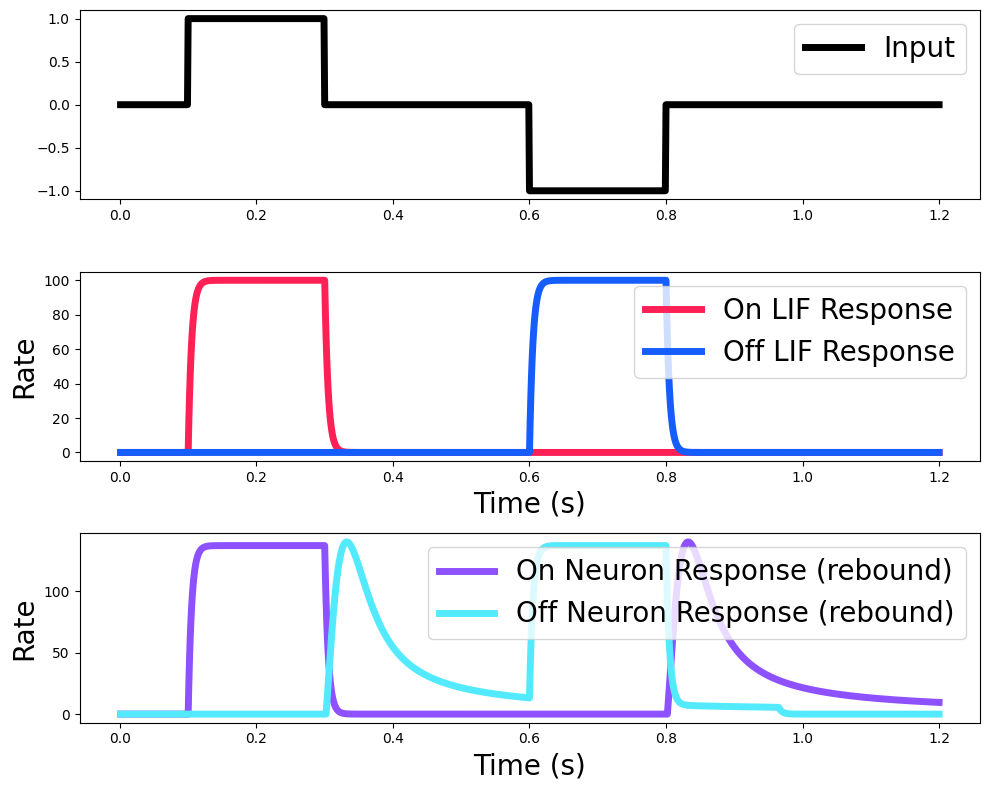

In [18]:
import nengo
import numpy as np
import matplotlib.pyplot as plt
from nengo.synapses import LinearFilter
from nengo.dists import Uniform

class Highpass(LinearFilter):
    """Simple high-pass filter: H(s) = (tau*s) / (tau*s + 1)."""
    tau = nengo.params.NumberParam("tau", low=0)

    def __init__(self, tau, **kwargs):
        super().__init__([tau, 0], [tau, 1], **kwargs)
        self.tau = tau


def add_presynaptic_rebound_from_ea_input(
    model, ea,
    input_dim=0,
    polarity=+1.0,
    tau_inhib=0.012,
    tau_delay=0.017,
    tau_rebound=0.010,
    k_inhib=12.0,
    k_rebound=6.0,
    clip_release=True,
):
    assert 0 <= input_dim < ea.dimensions

    with model:
        # Effective input from EA input dimension
        s_eff = nengo.Node(size_in=1, label="s_eff")
        nengo.Connection(
            ea.input[input_dim],
            s_eff,
            transform=[[float(np.sign(polarity) or 1.0)]],
            synapse=None,
        )

        # Half-wave rectification
        exc = nengo.Node(
            output=lambda t, x: max(x[0], 0.0),
            size_in=1,
            label="exc",
        )
        inhib = nengo.Node(
            output=lambda t, x: max(-x[0], 0.0),
            size_in=1,
            label="inhib",
        )
        nengo.Connection(s_eff, exc,   synapse=None)
        nengo.Connection(s_eff, inhib, synapse=None)

        # Two lowpass filters on inhibition
        inhib_lp = nengo.Node(size_in=1, label="inhib_lp")
        delay_lp = nengo.Node(size_in=1, label="delay_lp")
        nengo.Connection(inhib,    inhib_lp, synapse=nengo.Lowpass(tau_inhib))
        nengo.Connection(inhib_lp, delay_lp, synapse=nengo.Lowpass(tau_delay))

        # release_raw = delay_lp - inhib_lp
        rel_raw = nengo.Node(
            output=lambda t, x: x[0] - x[1],
            size_in=2, size_out=1,
            label="release_raw",
        )
        nengo.Connection(delay_lp, rel_raw[0], synapse=None)
        nengo.Connection(inhib_lp, rel_raw[1], synapse=None)

        if clip_release:
            release = nengo.Node(
                output=lambda t, x: max(x[0], 0.0),
                size_in=1,
                label="release_relu",
            )
            nengo.Connection(rel_raw, release, synapse=None)
        else:
            release = rel_raw

        rebound = nengo.Node(size_in=1, label="rebound")
        nengo.Connection(
            release,
            rebound,
            synapse=nengo.Lowpass(tau_rebound),
            transform=[[k_rebound]],
        )

        inhib_penalty = nengo.Node(size_in=1, label="inhib_penalty")
        nengo.Connection(
            inhib,
            inhib_penalty,
            synapse=None,
            transform=[[-k_inhib]],
        )

        # Connect to all neurons in the EA
        neuron_input = ea.add_neuron_input()
        n_total = ea.n_neurons_per_ensemble * ea.n_ensembles
        ones = np.ones((n_total, 1))

        nengo.Connection(exc,           neuron_input, transform=ones, synapse=None)
        nengo.Connection(rebound,       neuron_input, transform=ones, synapse=None)
        nengo.Connection(inhib_penalty, neuron_input, transform=ones, synapse=None)

    # Return some internal signals if needed
    return {
        "s_eff": s_eff,
        "exc": exc,
        "inhib": inhib,
        "inhib_lp": inhib_lp,
        "delay_lp": delay_lp,
        "release": release,
        "rebound": rebound,
        "inhib_penalty": inhib_penalty,
        "neuron_input": neuron_input,
    }


# -------- Build a minimal EA vs HPF comparison --------

model = nengo.Network(label="EA_HPFF_like_rebound_test")
with model:
    # Input: positive pulse 0.1s–0.3s
    def stimulus_fn(t):
        if 0.1 <= t < 0.3:
            return 1.0
        elif 0.6 <= t < 0.8:
            return -1.0
        else:
            return 0.0

    inp = nengo.Node(stimulus_fn, label="input")

    # Same neuron type as in the single-neuron demo
    neuron_type = nengo.LIFRate(tau_rc=0.005, tau_ref=0.001)

    # EnsembleArray with a single ensemble of a single neuron (equivalent to one neuron)
    ea_on = nengo.networks.EnsembleArray(
        n_neurons=1,  # per ensemble
        n_ensembles=1,
        neuron_type=neuron_type,
        encoders=nengo.dists.Choice([[1.0]]),
        intercepts=nengo.dists.Choice([0.0]),
        max_rates=Uniform(100, 100),
        label="EA_rebound",
    )

    ea_off = nengo.networks.EnsembleArray(
        n_neurons=1,  # per ensemble
        n_ensembles=1,
        neuron_type=neuron_type,
        encoders=nengo.dists.Choice([[-1.0]]),
        intercepts=nengo.dists.Choice([0.0]),
        max_rates=Uniform(100, 100),
        label="EA_rebound",
    )

    lif_on = nengo.networks.EnsembleArray(
        n_neurons=1,  # per ensemble
        n_ensembles=1,
        neuron_type=neuron_type,
        encoders=nengo.dists.Choice([[1.0]]),
        intercepts=nengo.dists.Choice([0.0]),
        max_rates=Uniform(100, 100),
        label="EA_rebound",
    )

    lif_off = nengo.networks.EnsembleArray(
        n_neurons=1,  # per ensemble
        n_ensembles=1,
        neuron_type=neuron_type,
        encoders=nengo.dists.Choice([[-1.0]]),
        intercepts=nengo.dists.Choice([0.0]),
        max_rates=Uniform(100, 100),
        label="EA_rebound",
    )

    # Connect the input as a 1D signal to EA.input[0]
    nengo.Connection(inp, ea_on.input, synapse=None)
    nengo.Connection(inp, ea_off.input, synapse=None)

    nengo.Connection(inp, lif_on.input, synapse=None)
    nengo.Connection(inp, lif_off.input, synapse=None)

    # Add rebound from EA input dim 0
    reb = add_presynaptic_rebound_from_ea_input(
        model,
        ea_on,
        input_dim=0,
        polarity=+1.0,
        tau_inhib=0.012,
        tau_delay=0.017,
        tau_rebound=0.010,
        k_inhib=12.0,
        k_rebound=6.0,
        clip_release=True,
    )
    reb = add_presynaptic_rebound_from_ea_input(
        model,
        ea_off,
        input_dim=0,
        polarity=-1.0,
        tau_inhib=0.012,
        tau_delay=0.017,
        tau_rebound=0.010,
        k_inhib=12.0,
        k_rebound=6.0,
        clip_release=True,
    )

    # A separate single neuron driven only by HPF on the same input
    ens_hpf = nengo.Ensemble(
        n_neurons=1,
        dimensions=1,
        neuron_type=neuron_type,
        encoders=nengo.dists.Choice([[1.0]]),
        intercepts=nengo.dists.Choice([0.0]),
        max_rates=Uniform(150, 150),
        label="neuron_hpf",
    )

    hp_tau = 0.015
    nengo.Connection(
        inp,
        ens_hpf.neurons,
        #synapse=Highpass(hp_tau),
        transform=[[1.0]],
    )

    # Probes
    p_inp = nengo.Probe(inp, synapse=None)
    p_ea_on_rate = nengo.Probe(ea_on.ea_ensembles[0].neurons, synapse=0.005)
    p_ea_off_rate = nengo.Probe(ea_off.ea_ensembles[0].neurons, synapse=0.005)
    p_hpf_rate = nengo.Probe(ens_hpf.neurons, synapse=0.005)
    p_rebound = nengo.Probe(reb["rebound"], synapse=None)
    P_lif_on = nengo.Probe(lif_on.ea_ensembles[0].neurons, synapse=0.005)
    P_lif_off = nengo.Probe(lif_off.ea_ensembles[0].neurons, synapse=0.005)


with nengo.Simulator(model, dt=0.001) as sim:
    sim.run(1.2)
fontsize = 20
t = sim.trange()

plt.figure(figsize=(10,8))

plt.subplot(3, 1, 1)
plt.plot(t, 1*sim.data[p_inp], label="Input",color="k",linewidth=5)
plt.legend(fontsize=fontsize)



plt.subplot(3, 1, 2)

plt.plot(t, sim.data[P_lif_on], label="On LIF Response",linewidth=5,color="#FF2056")
plt.plot(t, sim.data[P_lif_off], label="Off LIF Response",linewidth=5,color="#155DFC")
plt.ylabel("Rate",fontsize=fontsize)
plt.xlabel("Time (s)",fontsize=fontsize)
plt.legend(fontsize=fontsize)


plt.subplot(3, 1,3)

plt.plot(t, sim.data[p_ea_on_rate], label="On Neuron Response (rebound)",linewidth=5,color="#8E51FF")
plt.plot(t, sim.data[p_ea_off_rate], label="Off Neuron Response (rebound)",linewidth=5,color="#53EAFD")
plt.ylabel("Rate",fontsize=fontsize)
plt.xlabel("Time (s)",fontsize=fontsize)
plt.legend(fontsize=fontsize)



plt.tight_layout()
plt.show()
